In [1]:
import os
import cv2
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from glob import glob
import tensorflow as tf
from sklearn.manifold import TSNE


2026-05-12 12:41:00.595917: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1778589661.006952      23 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1778589661.121927      23 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1778589662.060930      23 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1778589662.060970      23 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1778589662.060973      23 computation_placer.cc:177] computation placer alr

In [2]:
# --- 1. SETUP & MODEL LOADING ---
# Path to your uploaded model (update this to your dataset name)
MODEL_PATH = '/kaggle/input/models/damonwangzc/gender-identifier-densenet121-version7/keras/default/1/best_gender_model (2).keras'

# Find the dataset CSV to pull sample images
csv_search = glob('/kaggle/input/datasets/organizations/nih-chest-xrays/data/Data_Entry_2017.csv', recursive=True)
csv_path = csv_search[0]
df = pd.read_csv(csv_path)

# Map image paths
dataset_root = os.path.dirname(csv_path)
all_image_paths = {os.path.basename(x): x for x in glob(os.path.join(dataset_root, '**', '*.png'), recursive=True)}
df['path'] = df['Image Index'].map(all_image_paths.get)
df = df.dropna(subset=['path'])

# Load the model
model = tf.keras.models.load_model(MODEL_PATH)

def medical_preprocessing(img):
    img = img.astype(np.uint8)
    clahe = cv2.createCLAHE(clipLimit=2.0, tileGridSize=(8, 8))
    if len(img.shape) == 2 or img.shape[2] == 1:
        img_clahe = clahe.apply(img if len(img.shape)==2 else img[:,:,0])
        img_final = cv2.cvtColor(img_clahe, cv2.COLOR_GRAY2RGB)
    else:
        lab = cv2.cvtColor(img, cv2.COLOR_RGB2LAB)
        l, a, b = cv2.split(lab)
        l2 = clahe.apply(l)
        lab = cv2.merge((l2, a, b))
        img_final = cv2.cvtColor(lab, cv2.COLOR_LAB2RGB)
    return img_final.astype(np.float32) / 255.0

I0000 00:00:1778589961.623862      23 gpu_device.cc:2019] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 13757 MB memory:  -> device: 0, name: Tesla T4, pci bus id: 0000:00:04.0, compute capability: 7.5
I0000 00:00:1778589961.630315      23 gpu_device.cc:2019] Created device /job:localhost/replica:0/task:0/device:GPU:1 with 13757 MB memory:  -> device: 1, name: Tesla T4, pci bus id: 0000:00:05.0, compute capability: 7.5
/usr/local/lib/python3.12/dist-packages/keras/src/saving/saving_lib.py:802: UserWarning: Skipping variable loading for optimizer 'adam', because it has 58 variables whereas the saved optimizer has 62 variables. 
  saveable.load_own_variables(weights_store.get(inner_path))


### 1. t-SNE Latent Space

Extracting features using GPU...


I0000 00:00:1778589972.231823      72 service.cc:152] XLA service 0x786ed80039a0 initialized for platform CUDA (this does not guarantee that XLA will be used). Devices:
I0000 00:00:1778589972.231856      72 service.cc:160]   StreamExecutor device (0): Tesla T4, Compute Capability 7.5
I0000 00:00:1778589972.231860      72 service.cc:160]   StreamExecutor device (1): Tesla T4, Compute Capability 7.5
I0000 00:00:1778589974.152249      72 cuda_dnn.cc:529] Loaded cuDNN version 91002


 3/32 ━━━━━━━━━━━━━━━━━━━━ 1s 63ms/step  

I0000 00:00:1778589990.242496      72 device_compiler.h:188] Compiled cluster using XLA!  This line is logged at most once for the lifetime of the process.


32/32 ━━━━━━━━━━━━━━━━━━━━ 48s 804ms/step
Squashing dimensions via t-SNE...


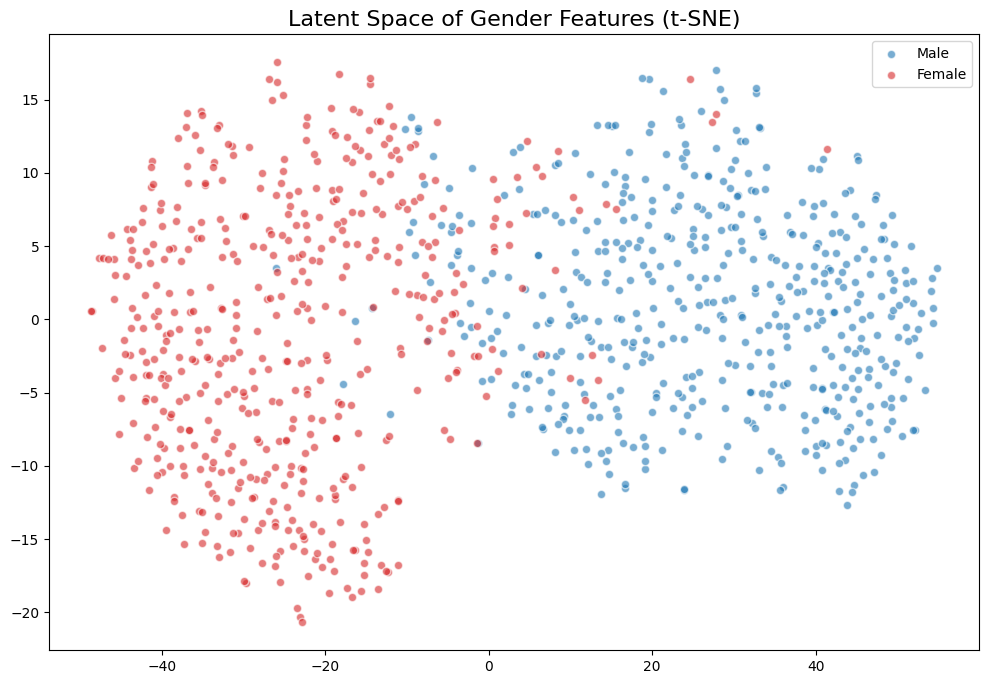

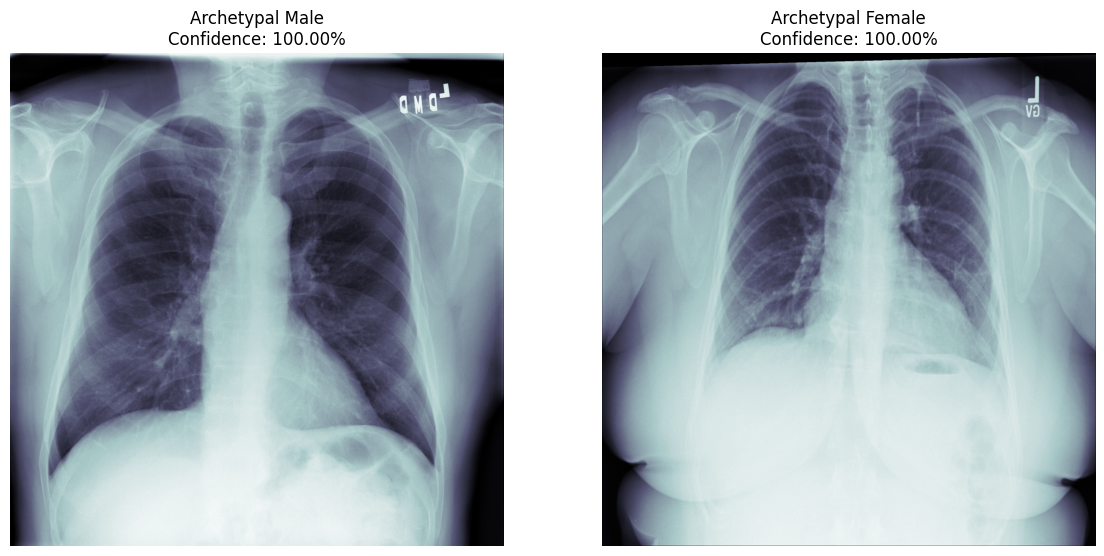

In [3]:
# Create a Dual-Output Model: Returns both Features AND Prediction
# This prevents having to run the model twice!
feature_layer = model.get_layer('global_average_pooling2d')
dual_output_model = tf.keras.models.Model(
    inputs=model.input,
    outputs=[feature_layer.output, model.output]
)

# --- 2. FAST GPU PIPELINE ---
# We take 500 Male and 500 Female samples
sample_size = 500
male_samples = df[df['Patient Gender'] == 'M'].sample(sample_size, random_state=42)
female_samples = df[df['Patient Gender'] == 'F'].sample(sample_size, random_state=42)
samples_df = pd.concat([male_samples, female_samples]).reset_index()

def load_and_preprocess(path):
    """Function for the TensorFlow data pipeline"""
    img = tf.io.read_file(path)
    img = tf.image.decode_png(img, channels=3)
    img = tf.image.resize(img, [320, 320])
    # Note: We use basic scaling here for speed in the pipeline
    # For 100% match with training, you can keep your CLAHE function 
    # but tf.image functions are much faster for GPU feeding.
    img = img / 255.0 
    return img

# Create a high-speed Dataset
batch_size = 32
ds = tf.data.Dataset.from_tensor_slices(samples_df['path'].values)
ds = ds.map(load_and_preprocess, num_parallel_calls=tf.data.AUTOTUNE)
ds = ds.batch(batch_size).prefetch(tf.data.AUTOTUNE)

print(f"Extracting features using GPU...")
# Run inference on the whole batch
features_all, probs_all = dual_output_model.predict(ds)

# Convert to numpy for visualization
X_features = features_all.astype('float32')
y_probs = probs_all.astype('float32')
y_actual = samples_df['Patient Gender'].map({'M': 0, 'F': 1}).values

# --- 3. T-SNE (Runs on CPU, but fast for 1000 points) ---
print("Squashing dimensions via t-SNE...")
tsne = TSNE(n_components=2, perplexity=30, random_state=42)
X_2d = tsne.fit_transform(X_features)

# --- 4. VISUALIZATION ---
plt.figure(figsize=(12, 8))
for gender_val, color, label in zip([0, 1], ['#1f77b4', '#d62728'], ['Male', 'Female']):
    indices = np.where(y_actual == gender_val)
    plt.scatter(X_2d[indices, 0], X_2d[indices, 1], c=color, label=label, alpha=0.6, edgecolors='white')

plt.title('Latent Space of Gender Features (t-SNE)', fontsize=16)
plt.legend()
plt.show()

# --- 5. ARCHETYPES ---
# Now y_probs has the correct shape because we got it during the GPU pass
most_male_idx = np.argmin(y_probs)
most_female_idx = np.argmax(y_probs)

fig, ax = plt.subplots(1, 2, figsize=(14, 7))
ax[0].imshow(plt.imread(samples_df.iloc[most_male_idx]['path']), cmap='bone')
ax[0].set_title(f"Archetypal Male\nConfidence: {100*(1-y_probs[most_male_idx][0]):.2f}%")
ax[0].axis('off')

ax[1].imshow(plt.imread(samples_df.iloc[most_female_idx]['path']), cmap='bone')
ax[1].set_title(f"Archetypal Female\nConfidence: {100*y_probs[most_female_idx][0]:.2f}%")
ax[1].axis('off')
plt.show()

### 2. XAI (Explainable AI)  - Grad-CAM Heatmap

/usr/local/lib/python3.12/dist-packages/keras/src/models/functional.py:241: UserWarning: The structure of `inputs` doesn't match the expected structure.
Expected: ['input_layer']
Received: inputs=Tensor(shape=(1, 320, 320, 3))
  warnings.warn(msg)


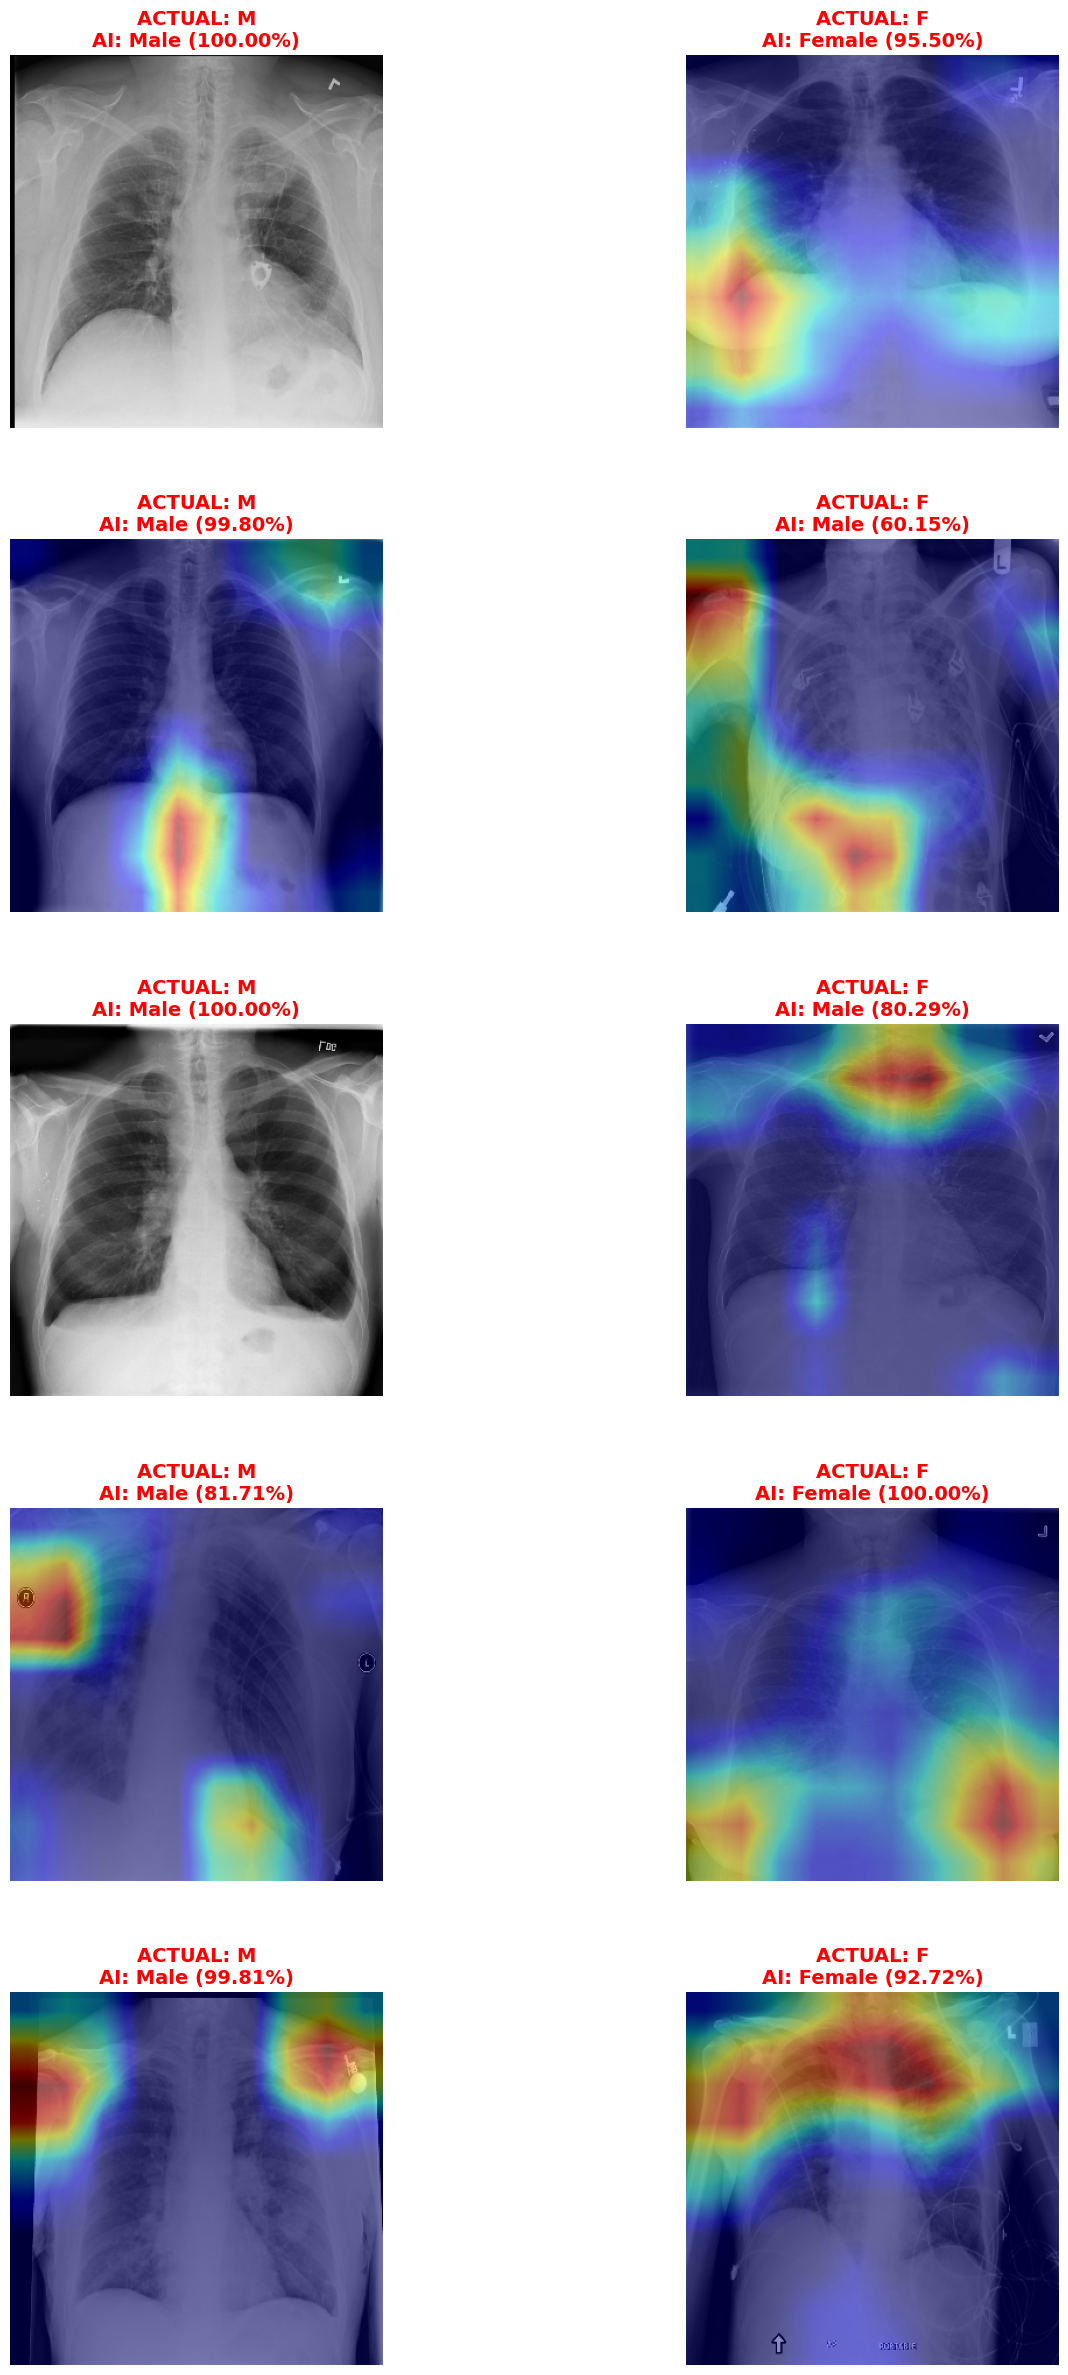

In [4]:
import tensorflow as tf
import numpy as np
import cv2
import matplotlib.pyplot as plt

def get_clean_gradcam(img_tensor, model, layer_name):
    # 1. Setup the gradient model
    grad_model = tf.keras.models.Model(
        model.inputs, [model.get_layer(layer_name).output, model.output]
    )
    
    # 2. Record gradients
    with tf.GradientTape() as tape:
        last_conv_layer_output, preds = grad_model(img_tensor)
        class_channel = preds[:, 0]

    # 3. Calculate and pool gradients
    grads = tape.gradient(class_channel, last_conv_layer_output)
    pooled_grads = tf.reduce_mean(grads, axis=(0, 1, 2))
    
    # 4. Calculate heatmap
    last_conv_layer_output = last_conv_layer_output[0]
    heatmap = last_conv_layer_output @ pooled_grads[..., tf.newaxis]
    heatmap = tf.squeeze(heatmap)
    
    # 5. ReLU and Normalize
    heatmap = tf.maximum(heatmap, 0)
    max_val = tf.math.reduce_max(heatmap)
    if max_val == 0: max_val = 1e-10 # Prevent div by zero
    heatmap /= max_val
    
    # --- CRITICAL FIX FOR OPENCV ERROR ---
    # Convert from TensorFlow Tensor to a standard CPU NumPy float32 array
    return heatmap.numpy().astype(np.float32)

# --- EXECUTION LOOP ---
fig, axes = plt.subplots(5, 2, figsize=(16, 30))
plt.subplots_adjust(hspace=0.3)


# Pick 4 distinct random samples
samples_to_test = []
for i in range (5):
  samples_to_test.append(df[df['Patient Gender'] == 'M'].sample(1).iloc[0])
  samples_to_test.append(df[df['Patient Gender'] == 'F'].sample(1).iloc[0])

for i, sample in enumerate(samples_to_test):
    row, col = i // 2, i % 2
    
    # 1. Load and Preprocess
    raw_img = cv2.imread(sample['path'])
    raw_img_rgb = cv2.cvtColor(raw_img, cv2.COLOR_BGR2RGB)
    img_resized = cv2.resize(raw_img_rgb, (320, 320))
    
    # Ensure fresh input tensor
    processed_input = medical_preprocessing(img_resized)
    input_tensor = np.expand_dims(processed_input, axis=0)
    
    # 2. Prediction (Using fresh call to model)
    # We clear any Keras session state to be 100% sure we get a fresh result
    preds_raw = model(input_tensor, training=False).numpy()
    p_female = float(preds_raw[0][0])
    
    if p_female > 0.5:
        gender_pred = "Female"
        conf = p_female
    else:
        gender_pred = "Male"
        conf = 1.0 - p_female
        
    # 3. Heatmap
    # Using 'relu' for DenseNet121
    heatmap_raw = get_clean_gradcam(input_tensor, model, 'relu')
    
    # Double check heatmap is not empty
    if heatmap_raw.ndim == 0: # If it's a single scalar
        heatmap_rescaled = np.zeros((320, 320), dtype=np.float32)
    else:
        heatmap_rescaled = cv2.resize(heatmap_raw, (320, 320))
    
    # 4. Plot
    ax = axes[row, col]
    ax.imshow(img_resized, cmap='bone')
    ax.imshow(heatmap_rescaled, alpha=0.45, cmap='jet')
    
    # UI Logic
    is_correct = gender_pred == sample['Patient Gender']
    title_color = 'green' if is_correct else 'red'
    ax.set_title(f"ACTUAL: {sample['Patient Gender']}\nAI: {gender_pred} ({conf:.2%})", 
                 color=title_color, fontweight='bold', fontsize=14)
    ax.axis('off')

plt.show()

### 3. Feature Matrix Visualization

Visualizing layers: ['conv1_conv', 'conv4_block11_2_conv', 'conv5_block16_concat']
1/1 ━━━━━━━━━━━━━━━━━━━━ 16s 16s/step


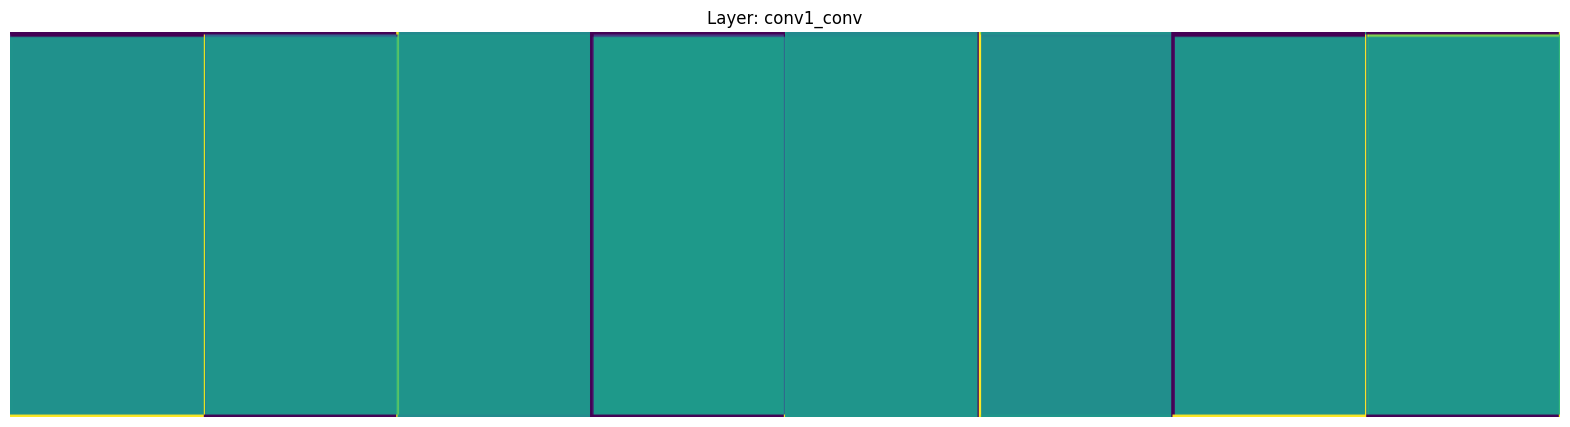

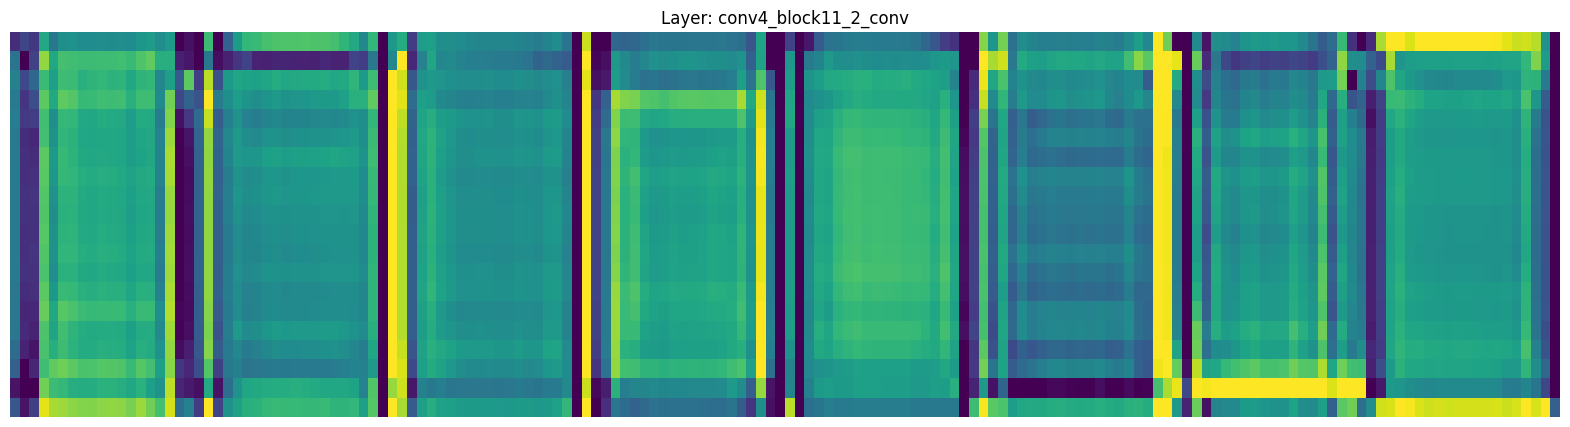

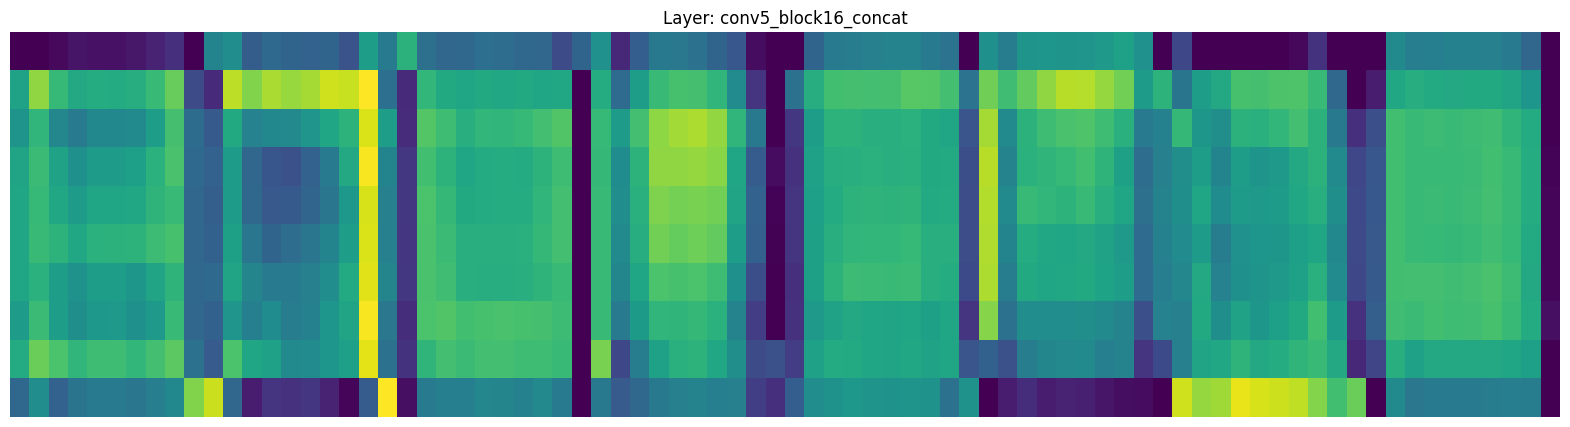

In [5]:
# --- 1. SETUP ---
# Pick a sample image
sample = df[df['Patient Gender'] == 'F'].sample(1).iloc[0]
img = plt.imread(sample['path'])
img_resized = cv2.resize(img, (320, 320))
img_tensor = np.expand_dims(medical_preprocessing(img_resized), axis=0)

# --- 2. DYNAMICALLY FIND LAYER NAMES ---
# This avoids "No such layer" errors by looking at the actual list in your model
all_layers = [layer.name for layer in model.layers if 'conv' in layer.name]

# We pick one from the start, middle, and end of the list
selected_layers = [
    all_layers[0],              # Very early (Edges)
    all_layers[len(all_layers)//2], # Middle (Textures)
    all_layers[-1]              # Very late (Complex Shapes)
]

print(f"Visualizing layers: {selected_layers}")

# Create the visualization model
visualization_model = tf.keras.models.Model(
    inputs=model.inputs, 
    outputs=[model.get_layer(name).output for name in selected_layers]
)

# Run the image through
successive_feature_maps = visualization_model.predict(img_tensor)

# --- 3. PLOT THE FEATURE MATRICES ---
for layer_name, feature_map in zip(selected_layers, successive_feature_maps):
    # Number of features in the map
    n_features = feature_map.shape[-1] 
    size = feature_map.shape[1] 
    
    # Create a grid for the first 8 filters
    display_grid = np.zeros((size, size * 8))
    
    for i in range(8):
        x = feature_map[0, :, :, i]
        # Normalize for visualization
        if x.std() > 0:
            x -= x.mean()
            x /= x.std()
            x *= 64
            x += 128
        x = np.clip(x, 0, 255).astype('uint8')
        display_grid[:, i * size : (i + 1) * size] = x

    plt.figure(figsize=(20, 5))
    plt.title(f"Layer: {layer_name}")
    plt.grid(False)
    plt.imshow(display_grid, aspect='auto', cmap='viridis')
    plt.axis('off')
    plt.show()

In [6]:
# import tensorflow as tf
# import numpy as np
# import cv2
# import matplotlib.pyplot as plt

# def get_clean_gradcam(img_tensor, model, layer_name):
#     # 1. Setup the gradient model
#     grad_model = tf.keras.models.Model(
#         model.inputs, [model.get_layer(layer_name).output, model.output]
#     )
    
#     # 2. Record gradients
#     with tf.GradientTape() as tape:
#         last_conv_layer_output, preds = grad_model(img_tensor)
#         class_channel = preds[:, 0]

#     # 3. Calculate and pool gradients
#     grads = tape.gradient(class_channel, last_conv_layer_output)
#     pooled_grads = tf.reduce_mean(grads, axis=(0, 1, 2))
    
#     # 4. Calculate heatmap
#     last_conv_layer_output = last_conv_layer_output[0]
#     heatmap = last_conv_layer_output @ pooled_grads[..., tf.newaxis]
#     heatmap = tf.squeeze(heatmap)
    
#     # 5. ReLU and Normalize
#     heatmap = tf.maximum(heatmap, 0)
#     max_val = tf.math.reduce_max(heatmap)
#     if max_val == 0: max_val = 1e-10 # Prevent div by zero
#     heatmap /= max_val
    
#     # --- CRITICAL FIX FOR OPENCV ERROR ---
#     # Convert from TensorFlow Tensor to a standard CPU NumPy float32 array
#     return heatmap.numpy().astype(np.float32)

# # --- EXECUTION LOOP ---
# fig, axes = plt.subplots(5, 2, figsize=(16, 30))
# plt.subplots_adjust(hspace=0.3)


# # Pick 4 distinct random samples
# samples_to_test = []
# for i in range (5):
#   samples_to_test.append(df[df['Patient Gender'] == 'M'].sample(1).iloc[0])
#   samples_to_test.append(df[df['Patient Gender'] == 'F'].sample(1).iloc[0])

# for i, sample in enumerate(samples_to_test):
#     row, col = i // 2, i % 2
    
#     # 1. Load and Preprocess
#     raw_img = cv2.imread(sample['path'])
#     raw_img_rgb = cv2.cvtColor(raw_img, cv2.COLOR_BGR2RGB)
#     img_resized = cv2.resize(raw_img_rgb, (320, 320))
    
#     # Ensure fresh input tensor
#     processed_input = medical_preprocessing(img_resized)
#     input_tensor = np.expand_dims(processed_input, axis=0)
    
#     # 2. Prediction (Using fresh call to model)
#     # We clear any Keras session state to be 100% sure we get a fresh result
#     preds_raw = model(input_tensor, training=False).numpy()
#     p_female = float(preds_raw[0][0])
    
#     if p_female > 0.5:
#         gender_pred = "Female"
#         conf = p_female
#     else:
#         gender_pred = "Male"
#         conf = 1.0 - p_female
        
#     # 3. Heatmap
#     # Using 'relu' for DenseNet121
#     heatmap_raw = get_clean_gradcam(input_tensor, model, 'relu')
    
#     # Double check heatmap is not empty
#     if heatmap_raw.ndim == 0: # If it's a single scalar
#         heatmap_rescaled = np.zeros((320, 320), dtype=np.float32)
#     else:
#         heatmap_rescaled = cv2.resize(heatmap_raw, (320, 320))
    
#     # 4. Plot
#     ax = axes[row, col]
#     ax.imshow(img_resized, cmap='bone')
#     ax.imshow(heatmap_rescaled, alpha=0.45, cmap='jet')
    
#     # UI Logic
#     is_correct = gender_pred == sample['Patient Gender']
#     title_color = 'green' if is_correct else 'red'
#     ax.set_title(f"ACTUAL: {sample['Patient Gender']}\nAI: {gender_pred} ({conf:.2%})", 
#                  color=title_color, fontweight='bold', fontsize=14)
#     ax.axis('off')

# plt.show()

In [7]:
# import os
# import cv2
# import numpy as np
# import pandas as pd
# import matplotlib.pyplot as plt
# from glob import glob
# import tensorflow as tf
# from sklearn.manifold import TSNE

# # --- 1. SETUP & MODEL LOADING ---
# MODEL_PATH = '/kaggle/input/models/damonwangzc/gender-identifier-densenet121-version7/keras/default/1/best_gender_model (2).keras'

# # Find the dataset CSV to pull sample images
# csv_search = glob('/kaggle/input/datasets/organizations/nih-chest-xrays/data/Data_Entry_2017.csv', recursive=True)
# csv_path = csv_search[0]
# dataset_root = os.path.dirname(csv_path)
# df = pd.read_csv(csv_path)
# all_image_paths = {os.path.basename(x): x for x in glob(os.path.join(dataset_root, '**', '*.png'), recursive=True)}
# df['path'] = df['Image Index'].map(all_image_paths.get)
# df = df.dropna(subset=['path'])

# # Load Model
# model = tf.keras.models.load_model(MODEL_PATH)

# # Create a Dual-Output Model: Returns both Features AND Prediction
# # This prevents having to run the model twice!
# feature_layer = model.get_layer('global_average_pooling2d')
# dual_output_model = tf.keras.models.Model(
#     inputs=model.input,
#     outputs=[feature_layer.output, model.output]
# )

# # --- 2. FAST GPU PIPELINE ---
# # We take 500 Male and 500 Female samples
# sample_size = 500
# male_samples = df[df['Patient Gender'] == 'M'].sample(sample_size, random_state=42)
# female_samples = df[df['Patient Gender'] == 'F'].sample(sample_size, random_state=42)
# samples_df = pd.concat([male_samples, female_samples]).reset_index()

# def load_and_preprocess(path):
#     """Function for the TensorFlow data pipeline"""
#     img = tf.io.read_file(path)
#     img = tf.image.decode_png(img, channels=3)
#     img = tf.image.resize(img, [320, 320])
#     # Note: We use basic scaling here for speed in the pipeline
#     # For 100% match with training, you can keep your CLAHE function 
#     # but tf.image functions are much faster for GPU feeding.
#     img = img / 255.0 
#     return img

# # Create a high-speed Dataset
# batch_size = 32
# ds = tf.data.Dataset.from_tensor_slices(samples_df['path'].values)
# ds = ds.map(load_and_preprocess, num_parallel_calls=tf.data.AUTOTUNE)
# ds = ds.batch(batch_size).prefetch(tf.data.AUTOTUNE)

# print(f"Extracting features using GPU...")
# # Run inference on the whole batch
# features_all, probs_all = dual_output_model.predict(ds)

# # Convert to numpy for visualization
# X_features = features_all.astype('float32')
# y_probs = probs_all.astype('float32')
# y_actual = samples_df['Patient Gender'].map({'M': 0, 'F': 1}).values

# # --- 3. T-SNE (Runs on CPU, but fast for 1000 points) ---
# print("Squashing dimensions via t-SNE...")
# tsne = TSNE(n_components=2, perplexity=30, random_state=42)
# X_2d = tsne.fit_transform(X_features)

# # --- 4. VISUALIZATION ---
# plt.figure(figsize=(12, 8))
# for gender_val, color, label in zip([0, 1], ['#1f77b4', '#d62728'], ['Male', 'Female']):
#     indices = np.where(y_actual == gender_val)
#     plt.scatter(X_2d[indices, 0], X_2d[indices, 1], c=color, label=label, alpha=0.6, edgecolors='white')

# plt.title('Latent Space of Gender Features (t-SNE)', fontsize=16)
# plt.legend()
# plt.show()

# # --- 5. ARCHETYPES ---
# # Now y_probs has the correct shape because we got it during the GPU pass
# most_male_idx = np.argmin(y_probs)
# most_female_idx = np.argmax(y_probs)

# fig, ax = plt.subplots(1, 2, figsize=(14, 7))
# ax[0].imshow(plt.imread(samples_df.iloc[most_male_idx]['path']), cmap='bone')
# ax[0].set_title(f"Archetypal Male\nConfidence: {100*(1-y_probs[most_male_idx][0]):.2f}%")
# ax[0].axis('off')

# ax[1].imshow(plt.imread(samples_df.iloc[most_female_idx]['path']), cmap='bone')
# ax[1].set_title(f"Archetypal Female\nConfidence: {100*y_probs[most_female_idx][0]:.2f}%")
# ax[1].axis('off')
# plt.show()